# INCM Assignment : 2

## Hodgkin-Huxley Model


Import Modules


In [16]:
import brian2 as b2
import matplotlib.pyplot as plt
import numpy as np
from neurodynex3.hodgkin_huxley import HH
from neurodynex3.tools import input_factory

In [ ]:
SPIKE_THRESHOLD = 20 + 65  # spike voltage threshold in HH voltage convention (mV)

In [ ]:
def plot_hh(state_monitor, title=None, figsize=(10, 8), save_path=None):
    fig, (ax_v, ax_g, ax_i) = plt.subplots(3, 1, figsize=figsize, sharex=True)

    ts = state_monitor.t / b2.ms

    # 1. Membrane potential (dodgerblue)
    ax_v.plot(ts, state_monitor.vm[0] / b2.mV, lw=1.5, color="blue", label="$V_m$")
    ax_v.axhline(
        SPIKE_THRESHOLD,
        color="hotpink",
        linestyle="--",
        alpha=0.7,
        label="Spike Threshold",
    )
    ax_v.set_ylabel("v [mV]", fontsize=14)
    ax_v.tick_params(axis="both", labelsize=12)
    ax_v.grid(True)
    ax_v.legend(loc="upper right", fontsize=12)

    # 2. Gating variables (original scheme with dodgerblue and alpha=0.8)
    ax_g.plot(ts, state_monitor.m[0], label="m", color="black", lw=1.5, alpha=0.8)
    ax_g.plot(ts, state_monitor.n[0], label="n", color="blue", lw=1.5, alpha=0.8)
    ax_g.plot(ts, state_monitor.h[0], label="h", color="red", lw=1.5, alpha=0.8)
    ax_g.set_ylabel("act. / inact.", fontsize=14)
    ax_g.set_ylim(-0.05, 1.05)
    ax_g.tick_params(axis="both", labelsize=12)
    ax_g.grid(True)
    ax_g.legend(loc="upper right", fontsize=12)

    # 3. Input Current (forestgreen)
    ax_i.plot(ts, state_monitor.I_e[0] / b2.uA, lw=1.5, color="green")
    ax_i.set_xlabel("t [ms]", fontsize=14)
    ax_i.set_ylabel(r"I [$\mu$A]", fontsize=14)
    ax_i.tick_params(axis="both", labelsize=12)
    ax_i.grid(True)

    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=500, bbox_inches="tight")
    plt.show()


## Part A: Classical Hodgkin-Huxley Model


### Q1 : Dynamics of an Action Potential


In [19]:
I_ext = 7.2 * b2.uA
current = input_factory.get_step_current(10, 12, b2.ms, I_ext)


In [ ]:
b2.defaultclock.dt = 0.01 * b2.ms  # set simulation timestep as 0.01 ms

In [21]:
state_monitor = HH.simulate_HH_neuron(current, 50 * b2.ms)

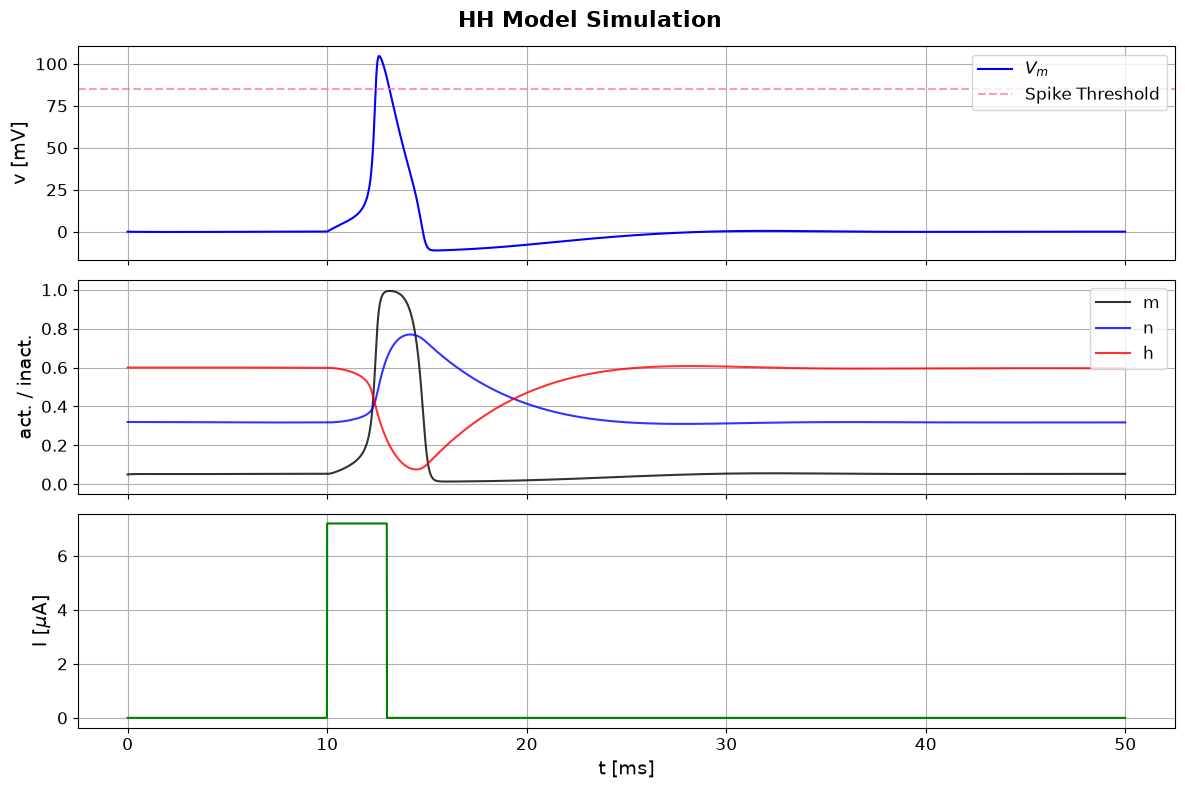

In [ ]:
plot_hh(
    state_monitor,
    title="HH Model Simulation",
    figsize=(12, 8),
    save_path="./figures/q1/HH_sim.png",
)

### Q2 : Effect of Sodium Conductance on Neuronal Excitability


In [23]:
def simulate_modified_HH_neuron(input_current, simulation_time):
    # neuron parameters
    El = 10.6 * b2.mV
    EK = -12 * b2.mV
    ENa = 115 * b2.mV
    gl = 0.3 * b2.msiemens
    gK = 36 * b2.msiemens
    gNa = 1.4 * 120 * b2.msiemens  # Modified by factor of 1.4
    C = 1 * b2.ufarad

    # forming HH model with differential equations
    eqs = """
    I_e = input_current(t,i) : amp
    membrane_Im = I_e + gNa*m**3*h*(ENa-vm) + \
        gl*(El-vm) + gK*n**4*(EK-vm) : amp
    alphah = .07*exp(-.05*vm/mV)/ms    : Hz
    alpham = .1*(25*mV-vm)/(exp(2.5-.1*vm/mV)-1)/mV/ms : Hz
    alphan = .01*(10*mV-vm)/(exp(1-.1*vm/mV)-1)/mV/ms : Hz
    betah = 1./(1+exp(3.-.1*vm/mV))/ms : Hz
    betam = 4*exp(-.0556*vm/mV)/ms : Hz
    betan = .125*exp(-.0125*vm/mV)/ms : Hz
    dh/dt = alphah*(1-h)-betah*h : 1
    dm/dt = alpham*(1-m)-betam*m : 1
    dn/dt = alphan*(1-n)-betan*n : 1
    dvm/dt = membrane_Im/C : volt
    """

    neuron = b2.NeuronGroup(1, eqs, method="exponential_euler")
    neuron.vm = 0
    neuron.m = 0.05
    neuron.h = 0.60
    neuron.n = 0.32

    st_mon = b2.StateMonitor(neuron, ["vm", "I_e", "m", "n", "h"], record=True)

    hh_net = b2.Network(neuron)
    hh_net.add(st_mon)
    hh_net.run(simulation_time)

    return st_mon


In [ ]:
def count_spikes_during_step(
    state_monitor, t_start=50 * b2.ms, t_end=350 * b2.ms, threshold_mV=85
):
    """
    Counts action potentials (upward crossings of threshold_mV)
    strictly during the current injection interval [t_start, t_end).
    """
    ts = state_monitor.t / b2.ms
    vm = state_monitor.vm[0] / b2.mV

    # Filter strictly within the current step window
    mask = (ts >= (t_start / b2.ms)) & (ts < (t_end / b2.ms))
    vm_step = vm[mask]

    # Detect upward crossings of 20 mV
    crossings = np.where((vm_step[:-1] < threshold_mV) & (vm_step[1:] >= threshold_mV))[
        0
    ]
    return len(crossings)


In [ ]:
def find_repetitive_firing_threshold(
    simulate_func, label="Neuron", I_range=(0.0, 15.0), dI=0.1, dt_search=0.05 * b2.ms
):
    b2.defaultclock.dt = dt_search
    currents = np.round(np.arange(I_range[0], I_range[1] + dI / 2, dI), 2)

    for amp in currents:
        current = input_factory.get_step_current(50, 350, b2.ms, amp * b2.uA)
        sm = simulate_func(current, 400 * b2.ms)
        spikes = count_spikes_during_step(sm)
        # print(rf"Spikes at {amp} \mu A using {simulate_func}: {spikes}")
        if spikes >= 3:
            print(
                f"[{label}] Repetitive firing threshold: I_ext = {amp:.1f} uA (fired {spikes} spikes)"
            )
            return amp

    print(f"[{label}] No repetitive firing detected up to {I_range[1]} uA.")
    return None

In [ ]:
# Perform threshold search for both neurons
I_th_std = find_repetitive_firing_threshold(HH.simulate_HH_neuron, label="Standard HH")
I_th_mod = find_repetitive_firing_threshold(
    simulate_modified_HH_neuron, label="Modified HH (1.4x gNa)"
)

[Standard HH] Repetitive firing threshold: I_ext = 6.2 uA (fired 3 spikes)
[Modified HH (1.4x gNa)] Repetitive firing threshold: I_ext = 1.2 uA (fired 13 spikes)


In [27]:
print(f"  Standard HH threshold : {I_th_std:.1f} uA")
print(f"  Modified HH threshold : {I_th_mod:.1f} uA")
print(f"  Reduction in threshold: {((I_th_std - I_th_mod) / I_th_std) * 100:.1f}%")

  Standard HH threshold : 6.2 uA
  Modified HH threshold : 1.2 uA
  Reduction in threshold: 80.6%


In [ ]:
# Switch to dt = 0.01 ms
b2.defaultclock.dt = 0.01 * b2.ms

# Standard HH near threshold (sub-threshold: 6.1 uA, threshold: 6.2 uA)
sm_std_sub = HH.simulate_HH_neuron(
    input_factory.get_step_current(50, 350, b2.ms, 6.1 * b2.uA), 400 * b2.ms
)
sm_std_th = HH.simulate_HH_neuron(
    input_factory.get_step_current(50, 350, b2.ms, 6.2 * b2.uA), 400 * b2.ms
)

# Modified HH near threshold (sub-threshold: 1.1 uA, threshold: 1.2 uA)
sm_mod_sub = simulate_modified_HH_neuron(
    input_factory.get_step_current(50, 350, b2.ms, 1.1 * b2.uA), 400 * b2.ms
)
sm_mod_th = simulate_modified_HH_neuron(
    input_factory.get_step_current(50, 350, b2.ms, 1.2 * b2.uA), 400 * b2.ms
)


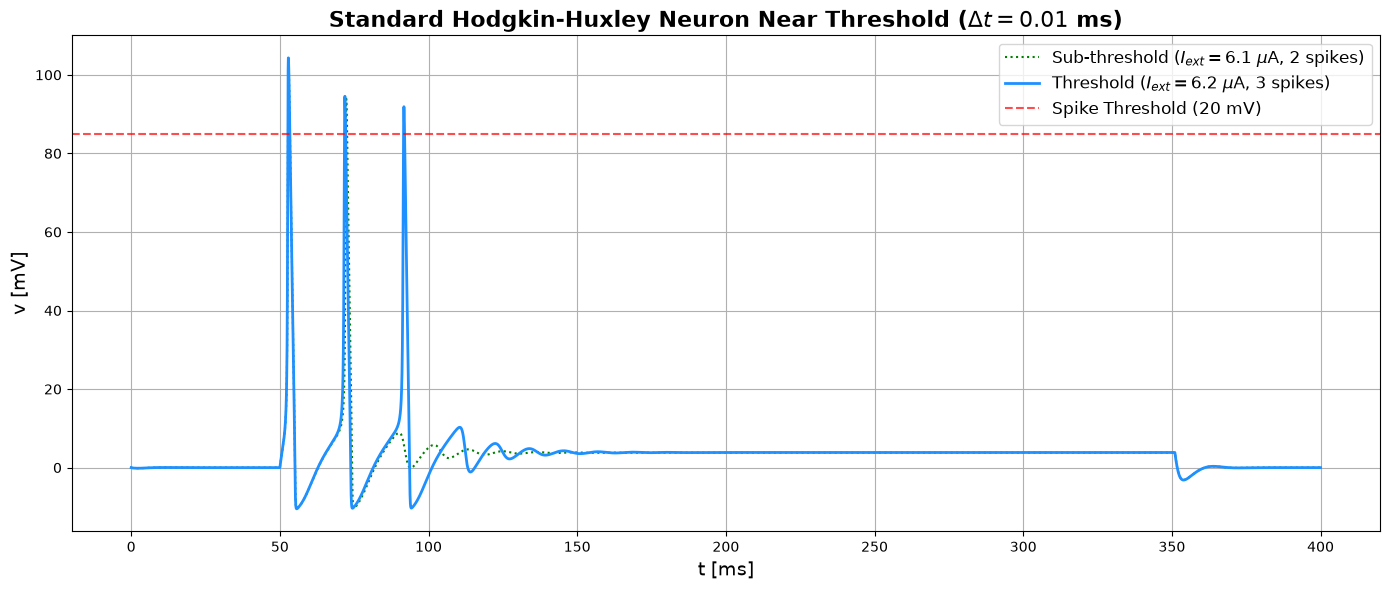

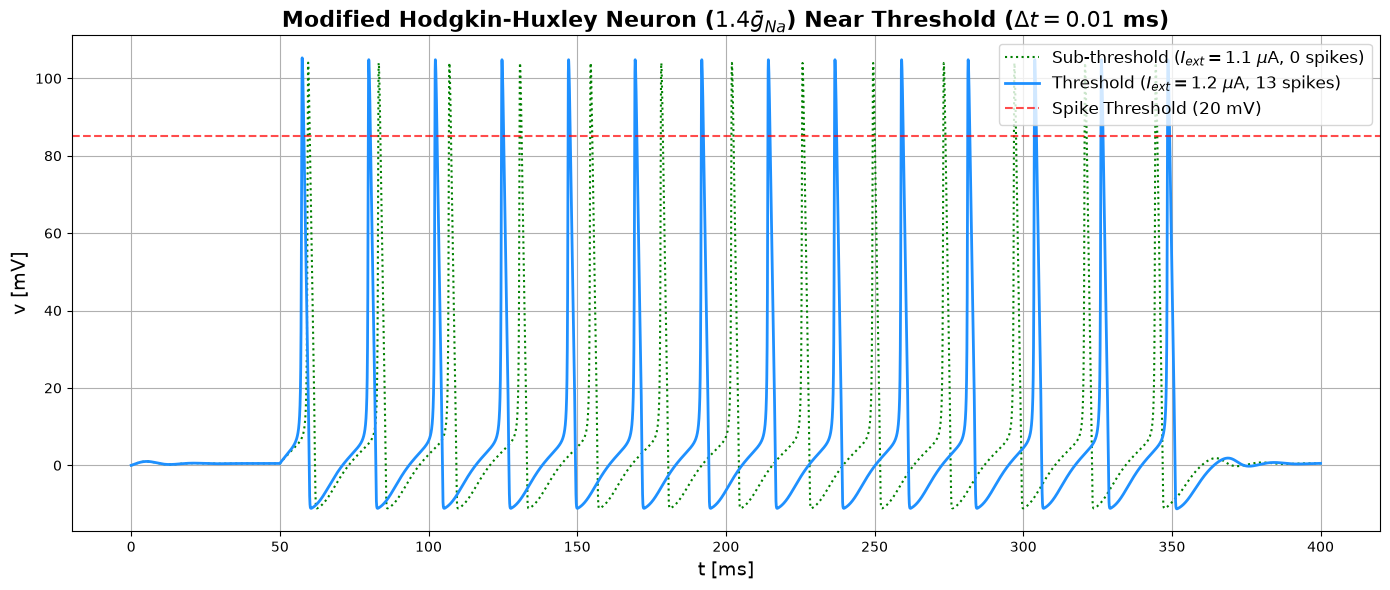

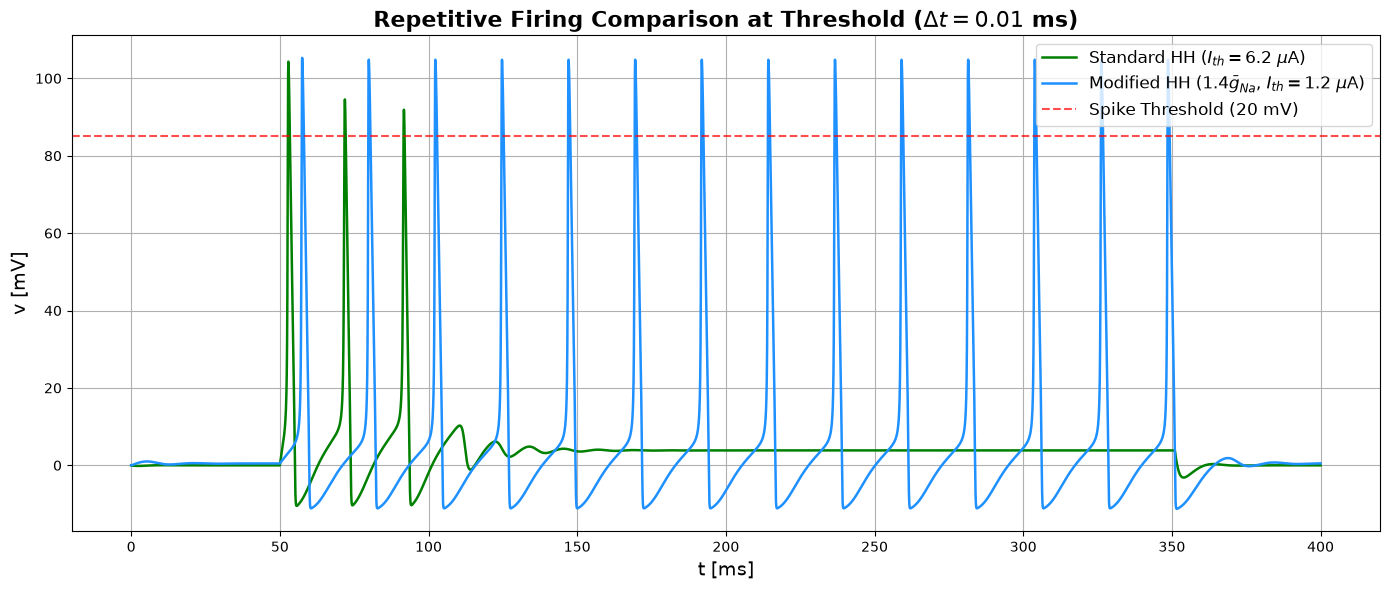

In [ ]:
# Figure 1: Standard HH near threshold
plt.figure(figsize=(14, 6))
ts = sm_std_th.t / b2.ms
plt.plot(
    ts,
    sm_std_sub.vm[0] / b2.mV,
    color="green",
    lw=1.5,
    linestyle=":",
    label=r"Sub-threshold ($I_{ext} = 6.1\ \mu$A, 2 spikes)",
)
plt.plot(
    ts,
    sm_std_th.vm[0] / b2.mV,
    color="dodgerblue",
    lw=2,
    label=r"Threshold ($I_{ext} = 6.2\ \mu$A, 3 spikes)",
)
plt.axhline(
    SPIKE_THRESHOLD,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Spike Threshold (20 mV)",
)
plt.title(
    rf"Standard Hodgkin-Huxley Neuron Near Threshold ($\Delta t = {b2.defaultclock.dt / b2.ms}$ ms)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("t [ms]", fontsize=14)
plt.ylabel("v [mV]", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    f"./figures/q2/standard_hh_threshold_{b2.defaultclock.dt / b2.ms}.png",
    dpi=500,
    bbox_inches="tight",
)
plt.show()

# Figure 2: Modified HH near threshold
plt.figure(figsize=(14, 6))
plt.plot(
    ts,
    sm_mod_sub.vm[0] / b2.mV,
    color="green",
    lw=1.5,
    linestyle=":",
    label=r"Sub-threshold ($I_{ext} = 1.1\ \mu$A, 0 spikes)",
)
plt.plot(
    ts,
    sm_mod_th.vm[0] / b2.mV,
    color="dodgerblue",
    lw=2,
    label=r"Threshold ($I_{ext} = 1.2\ \mu$A, 13 spikes)",
)
plt.axhline(
    SPIKE_THRESHOLD,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Spike Threshold (20 mV)",
)
plt.title(
    rf"Modified Hodgkin-Huxley Neuron ($1.4\bar{{g}}_{{Na}}$) Near Threshold ($\Delta t = {b2.defaultclock.dt / b2.ms}$ ms)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("t [ms]", fontsize=14)
plt.ylabel("v [mV]", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    f"./figures/q2/modified_hh_threshold_{b2.defaultclock.dt / b2.ms}.png",
    dpi=500,
    bbox_inches="tight",
)
plt.show()

# Figure 3: Side-by-side / Direct Comparison at Threshold
plt.figure(figsize=(14, 6))
plt.plot(
    ts,
    sm_std_th.vm[0] / b2.mV,
    color="green",
    lw=1.8,
    label=r"Standard HH ($I_{th} = 6.2\ \mu$A)",
)
plt.plot(
    ts,
    sm_mod_th.vm[0] / b2.mV,
    color="dodgerblue",
    lw=1.8,
    label=r"Modified HH ($1.4\bar{g}_{Na}$, $I_{th} = 1.2\ \mu$A)",
)
plt.axhline(
    SPIKE_THRESHOLD,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Spike Threshold (20 mV)",
)
plt.title(
    rf"Repetitive Firing Comparison at Threshold ($\Delta t = {b2.defaultclock.dt / b2.ms}$ ms)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("t [ms]", fontsize=14)
plt.ylabel("v [mV]", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    f"./figures/q2/comparison_threshold_{b2.defaultclock.dt / b2.ms}.png",
    dpi=500,
    bbox_inches="tight",
)
plt.show()


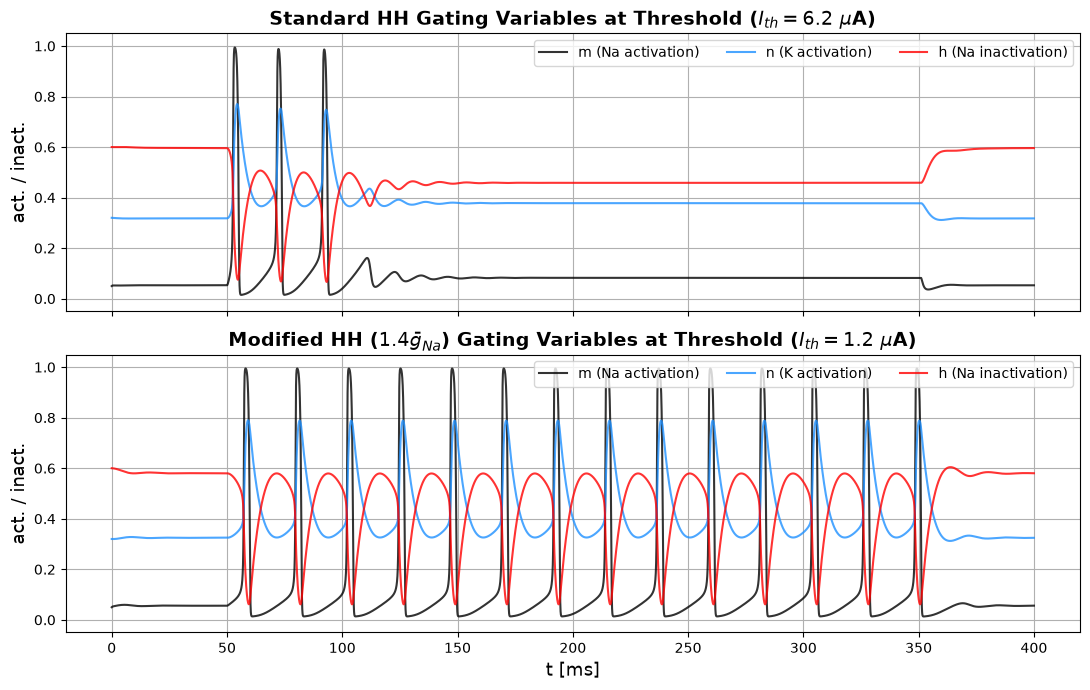

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ts = sm_std_th.t / b2.ms

# Standard HH Gating Variables (I = 6.2 uA)
ax1.plot(
    ts, sm_std_th.m[0], label="m (Na activation)", color="black", lw=1.5, alpha=0.8
)
ax1.plot(
    ts, sm_std_th.n[0], label="n (K activation)", color="dodgerblue", lw=1.5, alpha=0.8
)
ax1.plot(
    ts, sm_std_th.h[0], label="h (Na inactivation)", color="red", lw=1.5, alpha=0.8
)
ax1.set_ylabel("act. / inact.", fontsize=13)
ax1.set_ylim(-0.05, 1.05)
ax1.set_title(
    r"Standard HH Gating Variables at Threshold ($I_{th} = 6.2\ \mu$A)",
    fontsize=14,
    fontweight="bold",
)
ax1.legend(loc="upper right", fontsize=10, ncol=3)
ax1.grid(True)

# Modified HH Gating Variables (I = 1.2 uA)
ax2.plot(
    ts, sm_mod_th.m[0], label="m (Na activation)", color="black", lw=1.5, alpha=0.8
)
ax2.plot(
    ts, sm_mod_th.n[0], label="n (K activation)", color="dodgerblue", lw=1.5, alpha=0.8
)
ax2.plot(
    ts, sm_mod_th.h[0], label="h (Na inactivation)", color="red", lw=1.5, alpha=0.8
)
ax2.set_xlabel("t [ms]", fontsize=13)
ax2.set_ylabel("act. / inact.", fontsize=13)
ax2.set_ylim(-0.05, 1.05)
ax2.set_title(
    r"Modified HH ($1.4\bar{g}_{Na}$) Gating Variables at Threshold ($I_{th} = 1.2\ \mu$A)",
    fontsize=14,
    fontweight="bold",
)
ax2.legend(loc="upper right", fontsize=10, ncol=3)
ax2.grid(True)

plt.tight_layout()
plt.savefig(
    "./figures/q2/gating_comparison_threshold.png", dpi=300, bbox_inches="tight"
)
plt.show()


## Part B: Extending the Hodgkin–Huxley Model with a New Ion Channel


### Q3 : Characterizing the Assigned Ion Channel


#### (a)

- Ions carried by the channel: Calcium ions ($\text{Ca}^{2+}$)
- Ionic current: Inward, depolarizing calcium current $I_{\text{Ca}}$
- Reversal potential: $E_{\text{Ca,CP}} = 30.0\,\text{mV}$
- Activation gating variable: $m_{\text{Ca}}$
- Inactivation gating variable: $h_{\text{Ca}}$
- Powers of the gating variables:
  - Activation power: $p = 1.0$ (mpower: 1.0)
  - Inactivation power: $q = 1.0$ (hpower: 1.0)

The Brian2 implementation uses the inward-current convention, in which positive
current is depolarizing and is added directly to the membrane equation:

$$
I_{\text{Ca}} = \bar{g}_{\text{Ca}}m_{\text{Ca}}^{p}h_{\text{Ca}}^{q}
\left(E_{\text{Ca}} - V\right)
$$

For $V < E_{\text{Ca}}$, this current is positive and inward. This is equivalent
to the conventional outward-current form
$I_{\text{Ca}}^{\text{out}} = \bar{g}_{\text{Ca}}m_{\text{Ca}}^{p}h_{\text{Ca}}^{q}(V-E_{\text{Ca}})$,
but with the opposite sign.


#### (b)

1. **Activation Variable ($m$)**

   The activation variable $m$ describes the rapid, voltage-dependent opening of the channel:
   - **Differential Equation:**
     $$\frac{dm}{dt} = \frac{m_{\infty}(V) - m}{\tau_m(V)}$$
   - **Steady-State Activation ($m_{\infty}$):**
     $$m_{\infty}(V) = \frac{1}{1 + \exp\left(\dfrac{V - (-42.921064)}{-5.163208}\right)} = \frac{1}{1 + \exp\left(-\dfrac{V + 42.921064}{5.163208}\right)}$$
   - **Activation Time Constant ($\tau_m$):**
     $$
     \tau_m(V) = \begin{cases}
     -0.855809 + 1.493527 \cdot \exp\left(-\dfrac{V}{27.414182}\right)\,\text{ms}, & \text{if } V < -10\text{ mV} \\[10pt]
     1.0\,\text{ms}, & \text{if } V \ge -10\text{ mV}
     \end{cases}
     $$

---

2. **Inactivation Variable ($h$)**

   The inactivation variable $h$ represents the slower, voltage-dependent closing (inactivation) of the channel:
   - **Differential Equation:**
     $$\frac{dh}{dt} = \frac{h_{\infty}(V) - h}{\tau_h(V)}$$
   - **Steady-State Inactivation ($h_{\infty}$):**
     $$h_{\infty}(V) = \frac{1}{1 + \exp\left(\dfrac{V - (-72.907420)}{4.575763}\right)} = \frac{1}{1 + \exp\left(\dfrac{V + 72.907420}{4.575763}\right)}$$
   - **Inactivation Time Constant ($\tau_h$):**
     $$\tau_h(V) = 9.987873 + 0.002883 \cdot \exp\left(-\frac{V}{5.598574}\right)\,\text{ms}$$


#### (c)


In [ ]:
# 1. Voltage range as specified in Q3(c)
v_cp = np.linspace(-120, 60, 1000)

# 2. Steady-state activation and inactivation equations
m_inf = 1.0 / (1.0 + np.exp((v_cp - (-42.921064)) / (-5.163208)))
h_inf = 1.0 / (1.0 + np.exp((v_cp - (-72.907420)) / 4.575763))

# 3. Time constants (in ms)
tau_m = np.where(v_cp < -10.0, -0.855809 + 1.493527 * np.exp(-v_cp / 27.414182), 1.0)

# tau_h definition
tau_h = 9.987873 + 0.002883 * np.exp(-v_cp / 5.598574)

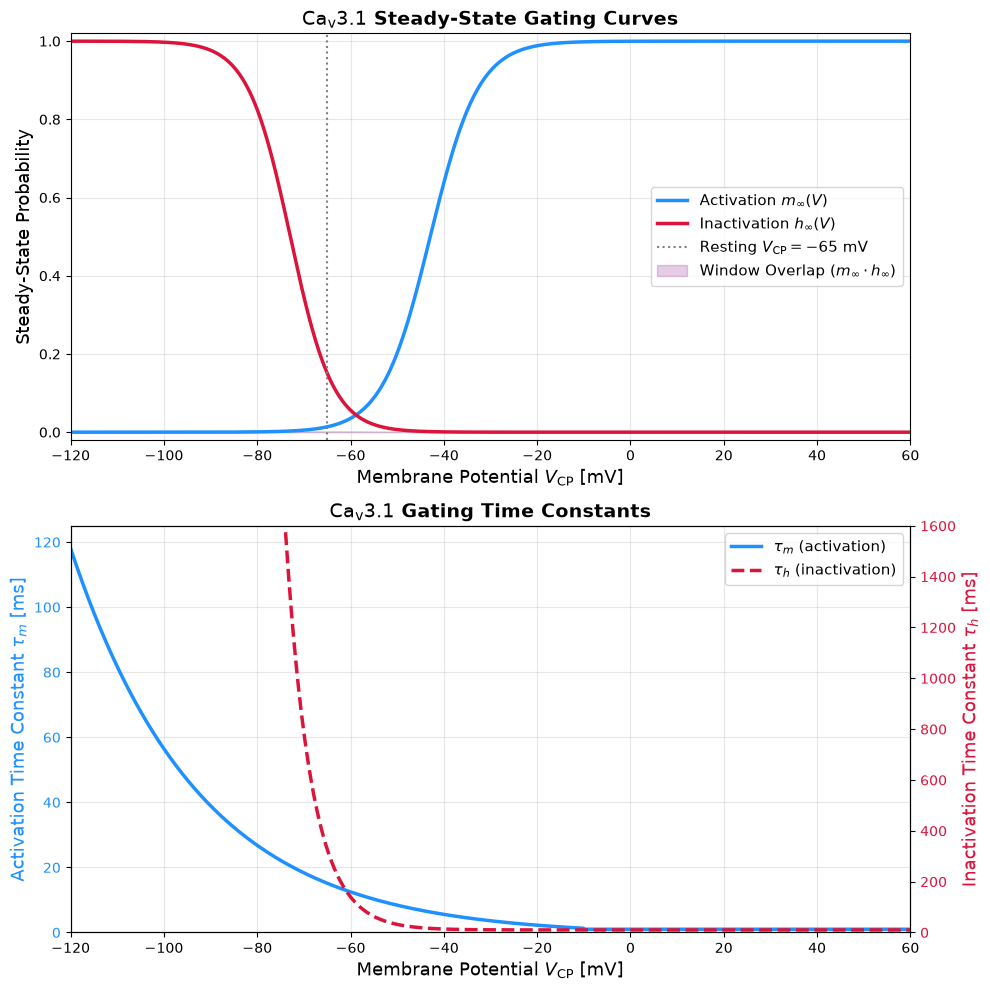

In [ ]:
# Create figure with 2 rows, 1 column and shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# -------------------------------------------------------------
# Top Subplot (Row 1): Steady-State Gating Curves
# -------------------------------------------------------------
ax1.plot(v_cp, m_inf, color="dodgerblue", lw=2.5, label=r"Activation $m_\infty(V)$")
ax1.plot(v_cp, h_inf, color="crimson", lw=2.5, label=r"Inactivation $h_\infty(V)$")

# Resting potential reference (-65 mV)
ax1.axvline(
    -65,
    color="gray",
    linestyle=":",
    lw=1.5,
    label=r"Resting $V_{\mathrm{CP}} = -65$ mV",
)

# Fill window overlap region
window_current = m_inf * h_inf
ax1.fill_between(
    v_cp,
    0,
    window_current,
    color="purple",
    alpha=0.2,
    label=r"Window Overlap ($m_\infty \cdot h_\infty$)",
)

ax1.set_title(
    r"$\mathrm{Ca_v3.1}$ Steady-State Gating Curves", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Steady-State Probability", fontsize=13)

# Enable x-axis label and tick labels on the upper plot
ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xlabel(r"Membrane Potential $V_{\mathrm{CP}}$ [mV]", fontsize=13)

ax1.set_xlim(-120, 60)
ax1.set_ylim(-0.02, 1.02)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="center right", fontsize=11)

# -------------------------------------------------------------
# Bottom Subplot (Row 2): Gating Time Constants
# -------------------------------------------------------------
color_m = "dodgerblue"
color_h = "crimson"

# Left y-axis for tau_m
ax2.plot(v_cp, tau_m, color=color_m, lw=2.5, label=r"$\tau_m$ (activation)")
ax2.set_xlabel(r"Membrane Potential $V_{\mathrm{CP}}$ [mV]", fontsize=13)
ax2.set_ylabel(r"Activation Time Constant $\tau_m$ [ms]", color=color_m, fontsize=13)
ax2.tick_params(axis="y", labelcolor=color_m)
ax2.set_ylim(0, 125)
ax2.grid(True, alpha=0.3)

# Right y-axis for tau_h
ax2_twin = ax2.twinx()
ax2_twin.plot(
    v_cp, tau_h, color=color_h, lw=2.5, linestyle="--", label=r"$\tau_h$ (inactivation)"
)
ax2_twin.set_ylabel(
    r"Inactivation Time Constant $\tau_h$ [ms]", color=color_h, fontsize=13
)
ax2_twin.tick_params(axis="y", labelcolor=color_h)
ax2_twin.set_ylim(0, 1600)

# Combine legends from both axes for ax2
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", fontsize=11)

ax2.set_title(
    r"$\mathrm{Ca_v3.1}$ Gating Time Constants", fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.savefig("figures/q3/cav3_1_kinetics_stacked.png", dpi=300, bbox_inches="tight")
plt.show()


#### (d)

We answer Q3(d) by walking through the two panels of our plot, reading off values and drawing conclusions directly from what we see.

---

### 1. At What Membrane Potentials Is the Channel Most Important?

**Reading the Steady-State Curves (Top Panel):**

We examine what the two gating variables look like at three important voltage ranges:

| Voltage Range                                              | $m_\infty$ (blue, activation)             | $h_\infty$ (red, inactivation)           | $m_\infty \cdot h_\infty$ (purple overlap) | Interpretation                                                                        |
| ---------------------------------------------------------- | ----------------------------------------- | ---------------------------------------- | ------------------------------------------ | ------------------------------------------------------------------------------------- |
| Deep hyperpolarization ($V_{\text{CP}} \le -90\text{ mV}$) | $\approx 0$ (channel closed)              | $\approx 1.0$ (fully available)          | $\approx 0$ (no current flows)             | Channels are available but not open. The neuron is "priming" the channel.             |
| Near rest ($V_{\text{CP}} \approx -65\text{ mV}$)          | $\approx 0$ (still closed)                | $\approx 0.15$ (mostly inactivated)      | $\approx 0$ (negligible)                   | Very few channels can contribute.                                                     |
| Subthreshold depolarization ($-55$ to $-35\text{ mV}$)     | Rises from $\approx 0.2$ to $\approx 0.9$ | Drops from $\approx 0.05$ to $\approx 0$ | Small but non-zero transiently             | If channels were previously primed ($h \approx 1$), they open here before $h$ closes. |

**Key visual observation:** The blue ($m_\infty$) and red ($h_\infty$) curves occupy **opposite ends** of the voltage axis. The blue curve is high at depolarized voltages; the red curve is high at hyperpolarized voltages. They only overlap in a narrow window (the purple shaded region near $-60\text{ mV}$), and even there the overlap is small.

**What this means:** For the channel to carry meaningful current, **both** $m$ and $h$ must be non-zero at the same time. At any fixed voltage, the steady-state product $m_\infty \cdot h_\infty$ is nearly zero everywhere. Therefore, the channel can only produce a large **transient** current — it needs the neuron to _start_ at a voltage where $h \approx 1$ (deeply hyperpolarized) and then _move_ to a voltage where $m$ activates ($-55$ to $-35\text{ mV}$), before $h$ has time to close.

---

### 2. How Will Adding This Channel Alter the Neuron's Behaviour?

**Reading the Time Constants (Bottom Panel):**

To determine whether $h$ stays open long enough for $m$ to activate, we compare their time constants:

| Voltage Range                                     | $\tau_m$ (blue, left axis)              | $\tau_h$ (red dashed, right axis)        | Ratio $\tau_h / \tau_m$           |
| ------------------------------------------------- | --------------------------------------- | ---------------------------------------- | --------------------------------- |
| In the activation zone ($-55$ to $-40\text{ mV}$) | $\approx 2\text{--}10\text{ ms}$ (fast) | $\approx 20\text{--}80\text{ ms}$ (slow) | $\sim 5\text{--}10\times$ slower  |
| At hyperpolarized voltages ($\le -80\text{ mV}$)  | $\approx 50\text{--}100\text{ ms}$      | $\approx 500\text{--}1500\text{ ms}$     | $\sim 10\text{--}15\times$ slower |

**Key visual observation:** $\tau_h$ (red dashed) is on a completely different scale compared to $\tau_m$ (blue solid) — note the right y-axis goes up to $1600\text{ ms}$ while the left y-axis only goes to $125\text{ ms}$. The inactivation gate $h$ is always **much slower** than the activation gate $m$.

**Putting the two panels together — how a rebound spike happens:**

Consider the following scenario: we hyperpolarize the neuron with a negative current and then release it.

1. **During hyperpolarization** (reading the top panel at $V \le -80\text{ mV}$): $h_\infty \approx 1.0$, so the inactivation gate fully opens. But $m_\infty \approx 0$, so the channel stays closed. No current flows yet — the channels are "loaded and ready."

2. **When we release the hyperpolarization**, the voltage rises back toward rest and enters the activation zone ($-55$ to $-40\text{ mV}$). Now:
   - $m$ opens rapidly (because $\tau_m \approx 2\text{--}10\text{ ms}$ is fast — bottom panel, left axis).
   - $h$ stays near $1.0$ for a while (because $\tau_h \approx 20\text{--}80\text{ ms}$ is much slower — bottom panel, right axis).

3. **For a brief moment** (a few milliseconds), **both gates are open**: $m > 0$ and $h \approx 1$. Since the calcium reversal potential is far above rest ($E_{\text{Ca}} = +30\text{ mV}$ in Channelpedia coordinates), a large **inward depolarizing current** flows:
   $$I_{\text{Ca}} = \bar{g}_{\text{Ca}} \cdot m \cdot h \cdot (V - E_{\text{Ca}}) < 0$$

4. This burst of inward current **pushes the membrane above the normal $\text{Na}^+$ spike threshold**, causing the neuron to fire an action potential — even though no depolarizing stimulus was applied. This is a **rebound spike**.

**In contrast**, if the neuron is stimulated from rest without prior hyperpolarization:

- At rest ($-65\text{ mV}$), $h_\infty \approx 0.15$ (top panel, red curve). Most channels are already inactivated and unavailable.
- So adding this channel will have **little effect** on standard action potentials that begin from rest.

**Summary of predictions:**

- The channel will cause the neuron to fire **rebound spikes after hyperpolarization** — a behaviour absent in the standard HH model.
- It will have **minimal effect on normal spiking** from rest, since most channels are inactivated at resting potential.
- A small **window current** (purple overlap near $-60\text{ mV}$) will provide a subtle depolarizing bias at rest.


### Q4


In [ ]:
def simulate_HH_neuron_with_new_channel(input_current, simulation_time):
    # Standard HH parameters (baseline)
    El = 10.6 * b2.mV
    EK = -12 * b2.mV
    ENa = 115 * b2.mV
    gl = 0.3 * b2.msiemens
    gK = 36 * b2.msiemens
    gNa = 120 * b2.msiemens  # Standard baseline gNa
    C = 1 * b2.ufarad

    # Cav3.1 channel parameters (Model ID 41)
    gCa = 20 * b2.msiemens  # Assigned conductance: 20 mS
    ECa = 95 * b2.mV  # ECa,HH = ECa,CP + 65 mV = 30 mV + 65 mV

    # Differential equations for HH + Cav3.1
    eqs = """
    I_e = input_current(t, i) : amp
    
    # Cav3.1 current: inward Ca2+ current
    ICa = gCa * m_ca * h_ca * (ECa - vm) : amp
    
    membrane_Im = I_e + gNa * m**3 * h * (ENa - vm) + \
                  gl * (El - vm) + gK * n**4 * (EK - vm) + ICa : amp

    # Standard HH gating kinetics
    alphah = .07 * exp(-.05 * vm / mV) / ms : Hz
    alpham = .1 * (25 * mV - vm) / (exp(2.5 - .1 * vm / mV) - 1) / mV / ms : Hz
    alphan = .01 * (10 * mV - vm) / (exp(1 - .1 * vm / mV) - 1) / mV / ms : Hz
    betah = 1. / (1 + exp(3. - .1 * vm / mV)) / ms : Hz
    betam = 4 * exp(-.0556 * vm / mV) / ms : Hz
    betan = .125 * exp(-.0125 * vm / mV) / ms : Hz
    
    dh/dt = alphah * (1 - h) - betah * h : 1
    dm/dt = alpham * (1 - m) - betam * m : 1
    dn/dt = alphan * (1 - n) - betan * n : 1
    
    # Channelpedia voltage conversion: V_CP = V_HH - 65 mV
    v_cp = vm - 65 * mV : volt

    # Cav3.1 steady-state activation and inactivation
    m_inf_ca = 1.0 / (1.0 + exp((v_cp / mV - (-42.921064)) / (-5.163208))) : 1
    h_inf_ca = 1.0 / (1.0 + exp((v_cp / mV - (-72.907420)) / 4.575763)) : 1

    # Cav3.1 time constants (in ms)
    # tau_m = -0.855809 + 1.493527 * exp(-v_cp / 27.414182) if v_cp < -10 mV else 1.0 ms
    cond_m = int(v_cp < -10 * mV) : 1
    tau_m_ca = (cond_m * (-0.855809 + 1.493527 * exp(-v_cp / mV / 27.414182)) + (1 - cond_m) * 1.0) * ms : second
    tau_h_ca = (9.987873 + 0.002883 * exp(-v_cp / mV / 5.598574)) * ms : second

    # Cav3.1 gating dynamics (power 1 for both m and h)
    dm_ca/dt = (m_inf_ca - m_ca) / tau_m_ca : 1
    dh_ca/dt = (h_inf_ca - h_ca) / tau_h_ca : 1

    dvm/dt = membrane_Im / C : volt
    """

    neuron = b2.NeuronGroup(1, eqs, method="exponential_euler")

    # Initial conditions
    neuron.vm = 0 * b2.mV
    neuron.m = 0.05
    neuron.h = 0.60
    neuron.n = 0.32

    # Initialize Cav3.1 gating variables at rest (V_CP = -65 mV)
    # m_inf(-65) = 1 / (1 + exp((-65 + 42.921064) / -5.163208))
    # h_inf(-65) = 1 / (1 + exp((-65 + 72.907420) / 4.575763))
    neuron.m_ca = 1.0 / (1.0 + np.exp((-65.0 - (-42.921064)) / -5.163208))
    neuron.h_ca = 1.0 / (1.0 + np.exp((-65.0 - (-72.907420)) / 4.575763))

    st_mon = b2.StateMonitor(
        neuron, ["vm", "I_e", "m", "n", "h", "m_ca", "h_ca"], record=True
    )

    hh_net = b2.Network(neuron, st_mon)
    hh_net.run(simulation_time)

    return st_mon


In [32]:
# 1. Set simulation timestep as specified (dt = 0.01 ms)
b2.defaultclock.dt = 0.01 * b2.ms

# 2. Simulation parameters as per prompt:
t_start = 50
t_end = 250
sim_time = 350 * b2.ms
I_ext = -2.0 * b2.uA

current = input_factory.get_step_current(t_start, t_end, b2.ms, I_ext)

# 3. Simulate standard HH neuron (baseline)
print("Simulating Standard HH neuron...")
sm_std = HH.simulate_HH_neuron(current, sim_time)

# 4. Simulate HH + Cav3.1 neuron (with T-type Ca2+ channel)
print("Simulating HH + Cav3.1 neuron...")
sm_cav = simulate_HH_neuron_with_new_channel(current, sim_time)

Simulating Standard HH neuron...
Simulating HH + Cav3.1 neuron...


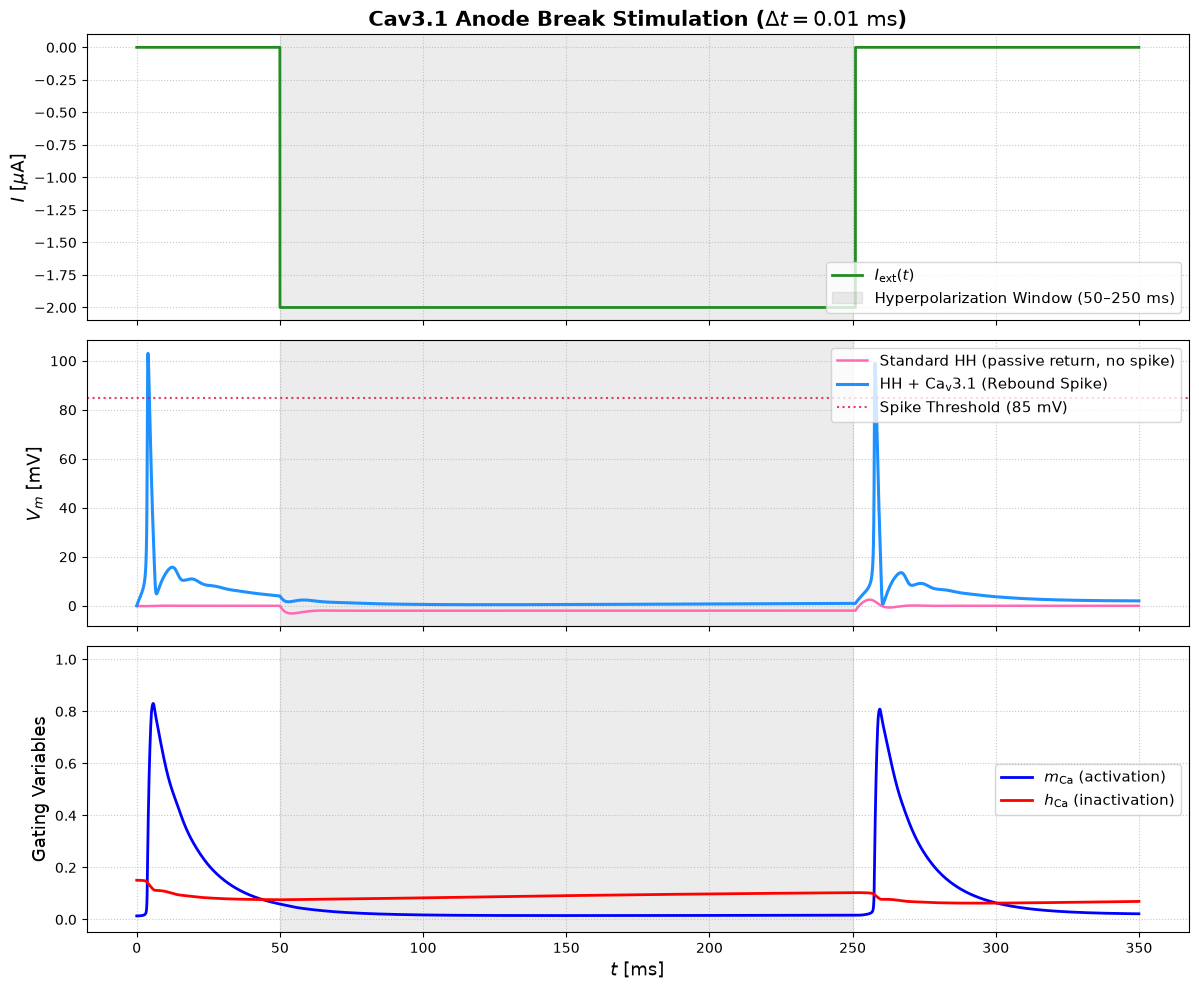

In [ ]:
# Create the 3-panel comparison figure
fig, (ax_i, ax_v, ax_g) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
ts = sm_cav.t / b2.ms

# Panel 1: Injected Current I_ext(t)
ax_i.plot(
    ts, sm_cav.I_e[0] / b2.uA, color="forestgreen", lw=2, label=r"$I_{\mathrm{ext}}(t)$"
)
ax_i.axvspan(
    50, 250, color="gray", alpha=0.15, label="Hyperpolarization Window (50–250 ms)"
)
ax_i.set_ylabel(r"$I\ [\mu\mathrm{A}]$", fontsize=13)
ax_i.set_title(
    rf"Cav3.1 Anode Break Stimulation ($\Delta t = {b2.defaultclock.dt / b2.ms}\ \mathrm{{ms}}$)",
    fontsize=15,
    fontweight="bold",
)
ax_i.legend(loc="lower right", fontsize=11)
ax_i.grid(True, linestyle=":", alpha=0.7)

# Panel 2: V(t) Comparison (Standard HH vs. HH + Cav3.1)
ax_v.plot(
    ts,
    sm_std.vm[0] / b2.mV,
    color="hotpink",
    lw=1.8,
    label="Standard HH (passive return, no spike)",
)
ax_v.plot(
    ts,
    sm_cav.vm[0] / b2.mV,
    color="dodgerblue",
    lw=2.2,
    label=r"HH + $\mathrm{Ca_v3.1}$ (Rebound Spike)",
)
ax_v.axhline(
    SPIKE_THRESHOLD,
    color="crimson",
    linestyle=":",
    lw=1.5,
    alpha=0.8,
    label=f"Spike Threshold ({SPIKE_THRESHOLD} mV)",
)
ax_v.axvspan(50, 250, color="gray", alpha=0.15)
ax_v.set_ylabel(r"$V_m\ [\mathrm{mV}]$", fontsize=13)
ax_v.legend(loc="upper right", fontsize=11)
ax_v.grid(True, linestyle=":", alpha=0.7)

# Panel 3: Cav3.1 Gating Variables (m_ca and h_ca)
ax_g.plot(
    ts, sm_cav.m_ca[0], color="blue", lw=2, label=r"$m_{\mathrm{Ca}}$ (activation)"
)
ax_g.plot(
    ts, sm_cav.h_ca[0], color="red", lw=2, label=r"$h_{\mathrm{Ca}}$ (inactivation)"
)
ax_g.axvspan(50, 250, color="gray", alpha=0.15)
ax_g.set_xlabel(r"$t\ [\mathrm{ms}]$", fontsize=13)
ax_g.set_ylabel("Gating Variables", fontsize=13)
ax_g.set_ylim(-0.05, 1.05)
ax_g.legend(loc="center right", fontsize=11)
ax_g.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.savefig("./figures/q4/cav31_rebound_simulation.png", dpi=300, bbox_inches="tight")
plt.show()


In [34]:
t_off = 250.0  # ms (stimulus offset time)

ts = sm_cav.t / b2.ms
vm = sm_cav.vm[0] / b2.mV

# Mask for post-hyperpolarization period
post_stim_mask = ts >= t_off
ts_post = ts[post_stim_mask]
vm_post = vm[post_stim_mask]

# Definition A: Peak Latency (to V_max)
peak_idx = np.argmax(vm_post)
t_peak = ts_post[peak_idx]
v_peak = vm_post[peak_idx]
latency_peak = t_peak - t_off

# Definition B: Threshold-Crossing Latency (to SPIKE_THRESHOLD = 20 mV)
crossings = np.where(vm_post >= SPIKE_THRESHOLD)[0]

if len(crossings) > 0:
    t_threshold = ts_post[crossings[0]]
    latency_threshold = t_threshold - t_off
else:
    t_threshold = None
    latency_threshold = None

# -----------------------------------------------------------
# Print Results
# -----------------------------------------------------------
print(f"Hyperpolarization removed at : {t_off:.2f} ms")
print(f"Rebound Spike Peak at        : {t_peak:.2f} ms (V_max = {v_peak:.2f} mV)")
print(f"  -> Peak Latency            : {latency_peak:.2f} ms")
if latency_threshold is not None:
    print(f"Threshold crossed (20 mV) at : {t_threshold:.2f} ms")
    print(f"  -> Threshold Latency       : {latency_threshold:.2f} ms")


Hyperpolarization removed at : 250.00 ms
Rebound Spike Peak at        : 257.84 ms (V_max = 99.02 mV)
  -> Peak Latency            : 7.84 ms
Threshold crossed (20 mV) at : 257.68 ms
  -> Threshold Latency       : 7.68 ms


### Effect of Adding the $\text{Ca}_{\text{v}}3.1$ Channel on Neuron Behaviour

Adding the $\text{Ca}_{\text{v}}3.1$ calcium channel changes the neuron's behaviour by causing it to fire a **rebound spike** right after a hyperpolarizing (negative) current is removed. In contrast, the standard Hodgkin–Huxley neuron simply returns passively to rest without firing.

---

#### Channel Kinetics $\longrightarrow$ Ionic Current $\longrightarrow$ Neuronal Behaviour

1. **During hyperpolarization ($50 \le t < 250\text{ ms}$):**  
   The negative current pulls the membrane voltage down below $-80\text{ mV}$. At this low voltage, the inactivation gate opens up almost fully ($h_{\text{Ca}}$ rises from $\approx 0.15$ to $\approx 1.0$), priming the channel. However, the activation gate stays closed ($m_{\text{Ca}} \approx 0$), so no current flows yet.

2. **Upon releasing the current ($t \ge 250\text{ ms}$):**  
   As the voltage begins rising back toward rest, it enters the channel's activation range. Because the activation gate is very fast ($\tau_m \approx 2\text{--}5\text{ ms}$) while the inactivation gate is much slower ($\tau_h \approx 20\text{--}50\text{ ms}$), $m_{\text{Ca}}$ opens rapidly before $h_{\text{Ca}}$ has time to close.

3. **Inward calcium current:**  
   With both gates temporarily open at the same time ($m_{\text{Ca}} \cdot h_{\text{Ca}} > 0$), and because the calcium reversal potential is very high ($E_{\text{Ca}} = +95\text{ mV}$), a strong burst of inward calcium current enters the neuron:
   $$I_{\text{Ca}} = g_{\text{Ca}} \cdot m_{\text{Ca}} \cdot h_{\text{Ca}} \cdot (E_{\text{Ca}} - V_m)$$

4. **Spike generation:**  
   This inward current pushes the membrane voltage past the spike threshold, triggering an action potential with a peak latency of **$7.84\text{ ms}$**.

---

#### Validation of Q3 Prediction

**Yes, the simulation directly confirms the prediction made in Q3.** The steady-state curves and time constants in Q3 showed that the channel is mostly inactivated at rest, gets primed by hyperpolarization, and opens transiently upon release to cause a rebound spike.


---
